<a href="https://colab.research.google.com/github/aneeshyder777/deep_learning/blob/main/Insurance_Prediction_Group_two.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [79]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import numpy as np
import warnings
warnings.filterwarnings('ignore')

In [80]:
df = pd.read_csv('/content/cleaned_insurance.csv')

In [81]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,Female,27,0,yes,southwest,16884.92400
1,18,Male,33,1,no,southeast,1725.55230
2,28,Male,33,3,no,southeast,4449.46200
3,33,Male,22,0,no,northwest,21984.47061
4,32,Male,28,0,no,northwest,3866.85520


In [82]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

In [83]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   int64  
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(1), int64(3), object(3)
memory usage: 73.3+ KB


In [84]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.319133,30.065022,1.075486,13093.992790
std,13.712911,5.964200,1.167811,11869.187487
min,18.000000,15.000000,0.000000,1121.873900
25%,27.000000,26.000000,0.000000,4925.098675
50%,39.000000,30.000000,1.000000,9382.033000
75%,51.000000,34.000000,2.000000,15215.260287
max,64.000000,53.000000,5.000000,63770.428010


In [85]:
df.isna().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [86]:
df.shape

(1338, 7)

In [87]:
df.nunique()

,0
age,47
sex,2
bmi,37
children,6
smoker,2
region,4
charges,1272


In [88]:
df['sex'].value_counts()

,count
sex,
Male,711
Female,627


In [89]:
df['smoker'].value_counts()

,count
smoker,
no,1079
yes,259


In [90]:
df['region'].value_counts()

,count
region,
southeast,408
southwest,312
northwest,310
northeast,308


In [91]:
df['children'].value_counts()

,count
children,
0,551
1,378
2,221
3,149
4,23
5,16


In [92]:
groupby_sex_smoker = df.groupby(['sex', 'smoker'])
groupby_sex_smoker.size()

sex     smoker
Female  no        520
        yes       107
Male    no        559
        yes       152
dtype: int64

<Axes: xlabel='children', ylabel='charges'>

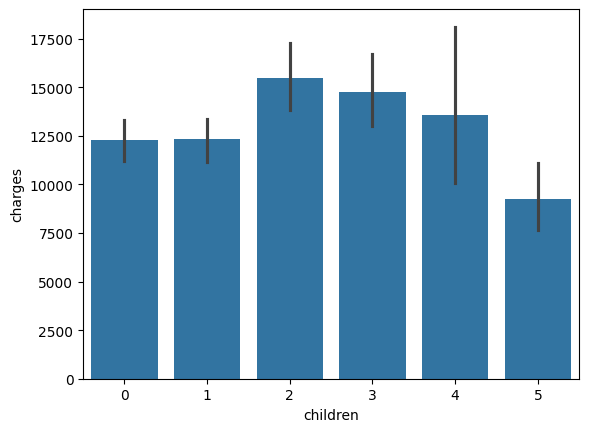

In [93]:
sns.barplot(x='children', y='charges', data=df)

<Axes: xlabel='smoker', ylabel='charges'>

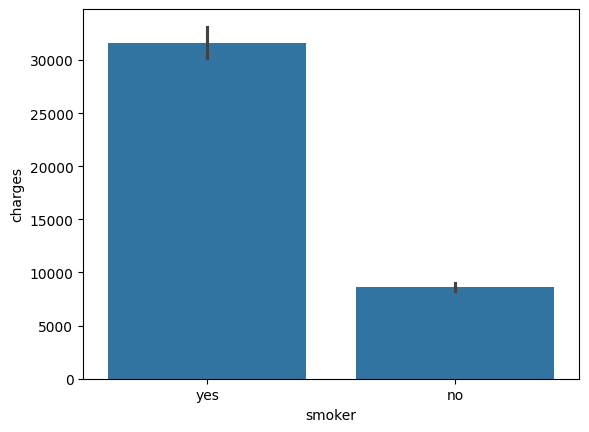

In [94]:
sns.barplot(x='smoker', y='charges', data=df)

<Axes: xlabel='region', ylabel='charges'>

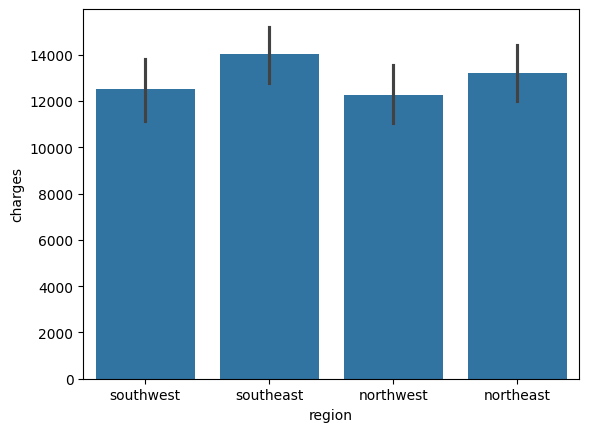

In [95]:
sns.barplot(x='region', y='charges', data=df)

<Axes: xlabel='sex', ylabel='charges'>

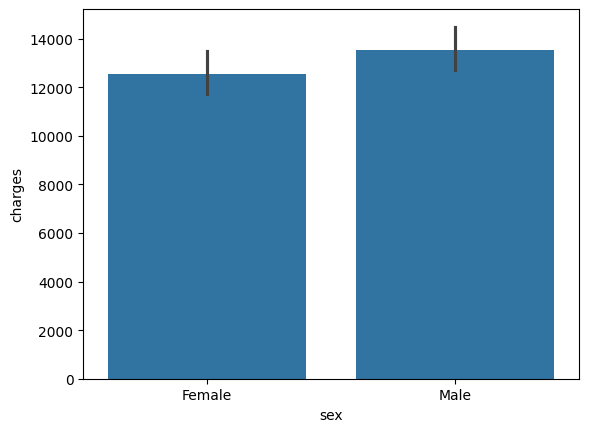

In [96]:
sns.barplot(x='sex', y='charges', data=df)

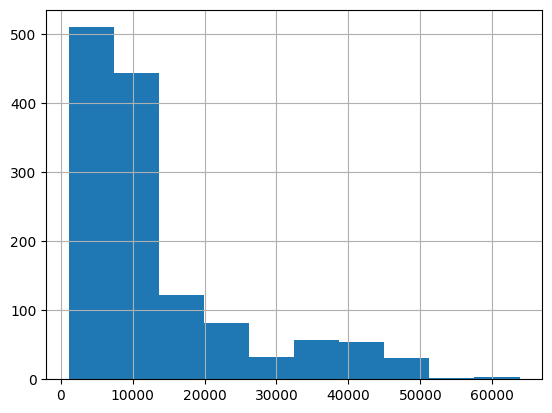

In [97]:
df.charges.hist()
plt.show()

In [98]:
pie = df['region'].value_counts()
a = pie.index
b = pie.values
fig = px.pie(df, values=b, names=a)
fig.show()

<Axes: >

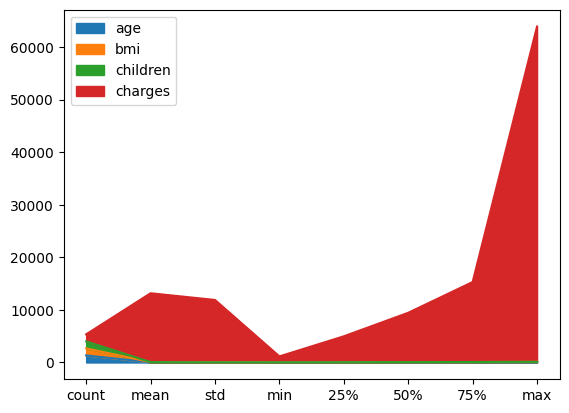

In [99]:
df.describe().plot(kind='area')

<Axes: xlabel='charges', ylabel='age'>

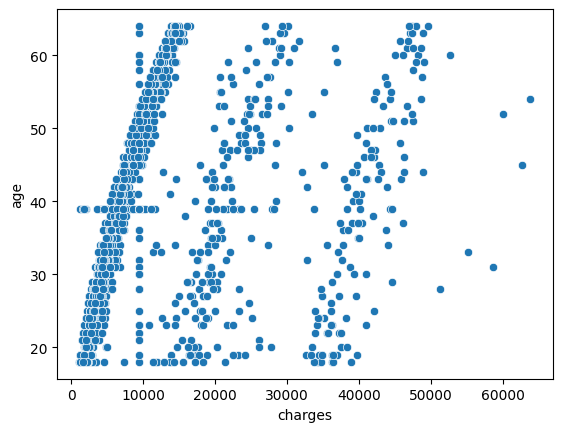

In [100]:
sns.scatterplot(x='charges', y='age', data=df, )

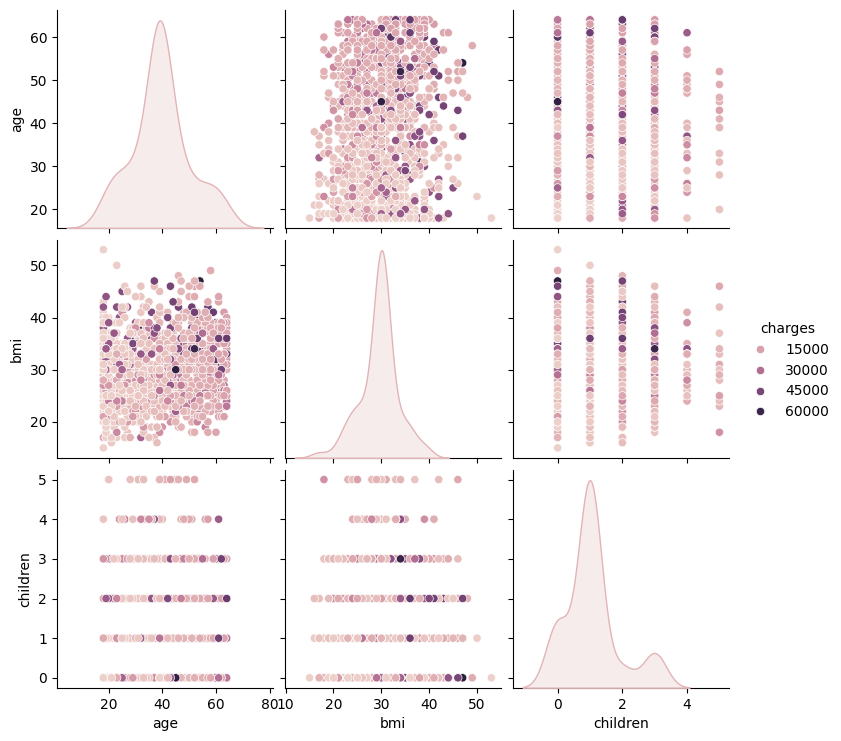

In [101]:
sns.pairplot(df, hue='charges')

<Axes: xlabel='bmi', ylabel='Count'>

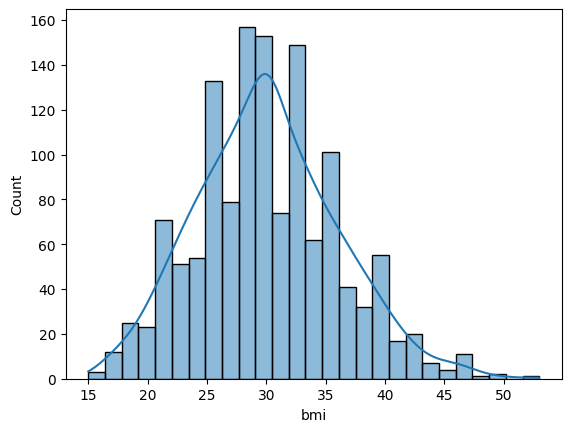

In [102]:
sns.histplot(df['bmi'], kde=True)

<Axes: xlabel='age', ylabel='Count'>

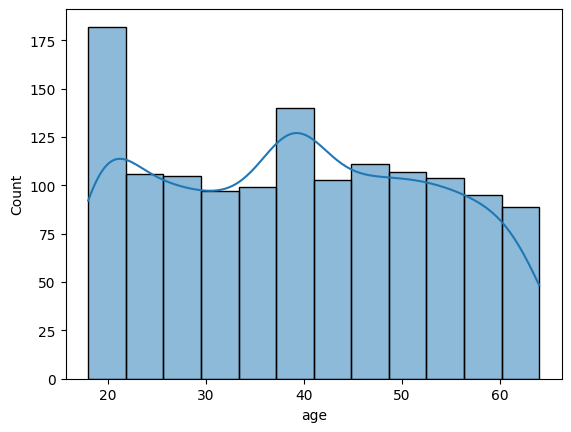

In [103]:
sns.histplot(df['age'], kde=True)

<Axes: xlabel='charges', ylabel='Count'>

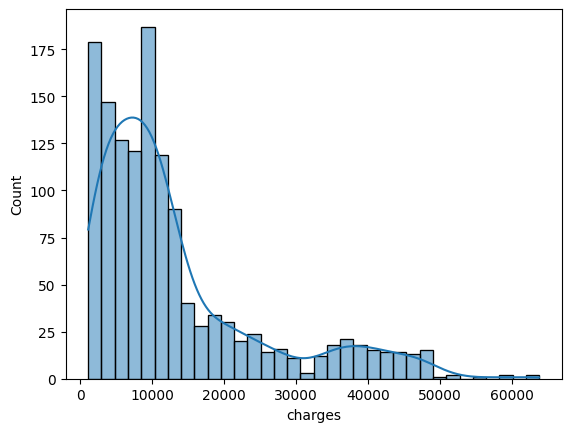

In [104]:
sns.histplot(df['charges'], kde=True)

In [105]:
corr_matrix = df.corr(numeric_only=True)
corr_matrix

,age,bmi,children,charges
age,1.000000,0.115276,0.050851,0.282194
bmi,0.115276,1.000000,0.016047,0.189349
children,0.050851,0.016047,1.000000,0.067652
charges,0.282194,0.189349,0.067652,1.000000


<Axes: >

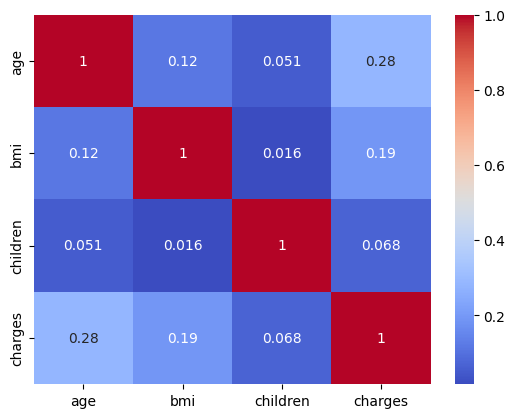

In [106]:
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')

In [107]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['region_label_encoded'] = le.fit_transform(df['region'])

In [108]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['gender_label_encoded'] = le.fit_transform(df['sex'])

In [109]:
df['smoker_label_encoded'] = le.fit_transform(df['smoker'])

In [110]:
df.head()

,age,sex,bmi,children,smoker,region,charges,region_label_encoded,gender_label_encoded,smoker_label_encoded
0,19,Female,27,0,yes,southwest,16884.92400,3,0,1
1,18,Male,33,1,no,southeast,1725.55230,2,1,0
2,28,Male,33,3,no,southeast,4449.46200,2,1,0
3,33,Male,22,0,no,northwest,21984.47061,1,1,0
4,32,Male,28,0,no,northwest,3866.85520,1,1,0


In [111]:
x = df[['age','bmi', 'children', 'gender_label_encoded', 'region_label_encoded', 'smoker_label_encoded']]
y = df['charges']

In [112]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [113]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [114]:
model_linear = LinearRegression()

In [115]:
model_linear.fit(x_train, y_train)

LinearRegression()

In [116]:
linear_score = model_linear.score(x_test, y_test)

In [117]:
print("Linear Regressor: ",linear_score)

Linear Regressor:  0.5589384544418291


In [118]:
models = {
    'Linear Regression': model_linear,

}
model_names = []
r2_scores = []

for name, model in models.items():
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mse)
    model_names.append(name)
    r2_scores.append(r2)
    print(f"{name}\n\tMSE: {mse},\n\tR2 Score: {r2},\n\tPercentage: {r2*100:.2f} %,\n\tRMSE: {rmse:.2f}\n")

Linear Regression
	MSE: 55259236.50880776,
	R2 Score: 0.5589384544418291,
	Percentage: 55.89 %,
	RMSE: 7433.66



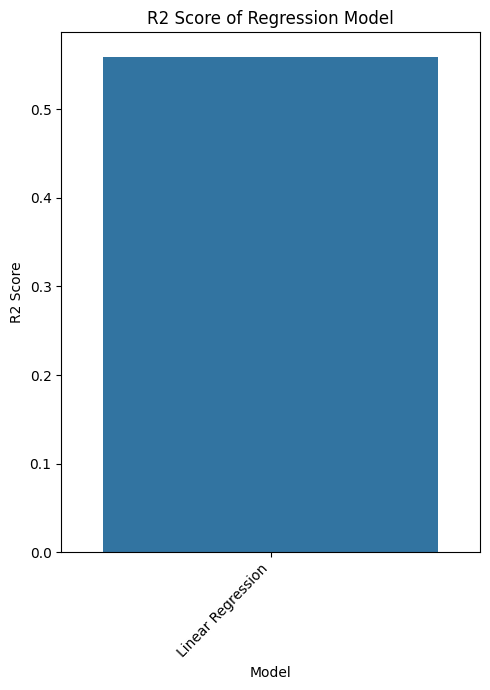

In [119]:
plt.figure(figsize=(5, 7))
sns.barplot(x=model_names, y=r2_scores)
plt.ylabel("R2 Score")
plt.xlabel("Model")
plt.title("R2 Score of Regression Model")
plt.xticks(rotation=46, ha='right')
plt.tight_layout()
plt.show()

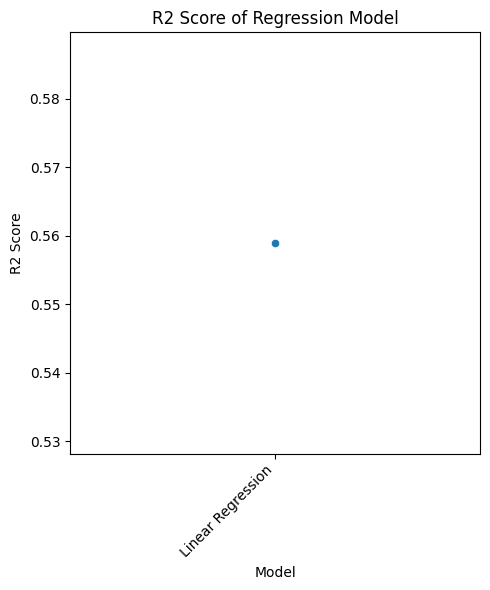

In [120]:
plt.figure(figsize=(5, 6))
sns.scatterplot(x=model_names, y=r2_scores)
plt.ylabel("R2 Score")
plt.xlabel("Model")
plt.title("R2 Score of Regression Model")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()